# 🎮 **STEAM PRICE INTELLIGENCE SYSTEM**

## 📌 **PROJECT OVERVIEW**

The **Steam Price Intelligence System** is an end-to-end machine learning project designed to analyze Steam game metadata and recommend optimal pricing strategies for indie game developers.

This system combines structured features (genre, reviews, release data, playtime, etc.) with natural language processing on game descriptions to understand how different factors influence game pricing in the Steam marketplace.

The goal is to move beyond simple price prediction and develop a data-driven pricing recommendation framework.

---


## 🎯 **PROBLEM STATEMENT**

Pricing is one of the most critical decisions for indie game developers.

Many games may be:

* Underpriced, leaving potential revenue unrealized
* Overpriced, reducing sales volume
* Priced without sufficient data-driven insight

The objective of this project is to:

* Analyze historical Steam game data
* Identify key features that influence pricing
* Build regression and classification models
* Provide an intelligent price recommendation range based on game attributes

This system aims to help developers make strategic pricing decisions backed by machine learning insights.

---

# **02 – DATA PREPROCESSING AND FEATURE ENGINEERING**

This notebook focuses on transforming the raw Steam dataset into a **clean, structured, and model-ready format** through systematic data preprocessing and feature engineering.

The objective of this phase is to:

* Handle missing values and remove high-null columns
* Convert placeholder and invalid values (e.g., negative indicators)
* Treat extreme outliers and skewed numerical distributions
* Standardize and transform relevant features
* Engineer meaningful variables from structured data
* Prepare textual metadata for NLP-based modeling

The transformations applied in this stage ensure that the dataset is **consistent, reliable, and suitable for regression modeling**, while enabling integration of both structured numerical features and transformer-based text representations.

---

In [1]:
'''Importing necessary libraries for data analysis and visualization.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [ ]:
# Loading the dataset from the specified path into a DataFrame.
df = pd.read_csv('games_march2025_cleaned.csv')

In [3]:
# Displaying the first few rows of the DataFrame to understand its structure and contents.
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


## **1.MISSING VALUE TREATMENT AND FEATURE ELIMINATION**

In [4]:
# print the columns with null values and the number of null values in each column 

null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])
print(f"Total number of rows: {len(df)}")

detailed_description      197
about_the_game            220
short_description         120
reviews                 79217
website                 48504
support_url             45508
support_email           10820
metacritic_url          86071
notes                   72975
score_rank              89579
dtype: int64
Total number of rows: 89618


In [5]:
# print percentage of null values in each column and the total number of rows in the dataset
null_percentages = (null_counts / len(df)) * 100
print("Percentage of null values in each column:")
print(null_percentages[null_percentages > 0])
print(f"Total number of rows: {len(df)}")

Percentage of null values in each column:
detailed_description     0.219822
about_the_game           0.245486
short_description        0.133902
reviews                 88.394073
website                 54.123056
support_url             50.779977
support_email           12.073467
metacritic_url          96.042090
notes                   81.428954
score_rank              99.956482
dtype: float64
Total number of rows: 89618


In [6]:
# checking the categorical columns and length of unique values in each categorical column
categorical_columns = df.select_dtypes(include=['object']).columns
print("Categorical columns and number of unique values in each column:")
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Categorical columns and number of unique values in each column:
name: 88899 unique values
release_date: 4459 unique values
detailed_description: 89075 unique values
about_the_game: 89040 unique values
short_description: 88586 unique values
reviews: 10291 unique values
header_image: 89587 unique values
website: 33321 unique values
support_url: 29309 unique values
support_email: 48174 unique values
metacritic_url: 3507 unique values
notes: 13946 unique values
supported_languages: 14560 unique values
full_audio_languages: 2882 unique values
packages: 75740 unique values
developers: 56478 unique values
publishers: 49798 unique values
categories: 7471 unique values
genres: 2689 unique values
screenshots: 89482 unique values
movies: 87183 unique values
estimated_owners: 15 unique values
tags: 70420 unique values


In [7]:
# filtering out columns with object data type
object_columns = df.select_dtypes(include=['object']).columns
print("Columns with object data type:")
print(object_columns)

Columns with object data type:
Index(['name', 'release_date', 'detailed_description', 'about_the_game',
       'short_description', 'reviews', 'header_image', 'website',
       'support_url', 'support_email', 'metacritic_url', 'notes',
       'supported_languages', 'full_audio_languages', 'packages', 'developers',
       'publishers', 'categories', 'genres', 'screenshots', 'movies',
       'estimated_owners', 'tags'],
      dtype='object')


In [8]:
# dropping columns that are not relevant for price prediction

columns_to_drop = ['header_image',          # irrelevant colummn
                   'detailed_description',  # planning to keep short_description
                   'about_the_game',        # same reason as detailed_description
                   'screenshots',           # 91440 unique values
                   'movies',                # 87235 unique values
                
                   # dropping columns with more than 50% null values
                   'reviews', 
                   'about_the_game',
                   'website',
                   'support_url',
                   'support_email',         # even it has 16% null values we cant use this column for modeling
                   'metacritic_url',
                   'notes',
                   'score_rank',

                   # dropping columns with free keyword in the name to avoid data leakage
                   'genres',
                   'tags'
                   ]

In [9]:
# dropping the columns from the DataFrame
cleaned_df = df.drop(columns=columns_to_drop)

In [10]:
# dropping nulls
cleaned_df.dropna(inplace=True)

In [11]:
remaining_nulls = cleaned_df.isnull().sum()

print(f"Total Remaining Null Values: {remaining_nulls.sum()}")

if remaining_nulls.sum() > 0:
    display(remaining_nulls[remaining_nulls > 0])

Total Remaining Null Values: 0


### **IMPLEMENTATION**

In this step, non-relevant and high-null columns were removed to streamline the dataset.

* Calculated null percentages for all features.
* Dropped columns with **more than 50% missing values** (`reviews`, `website`, `support_url`, `metacritic_url`, `notes`, `score_rank`).
* Removed irrelevant or non-predictive metadata (`header_image`, `screenshots`, `movies`, `support_email`).
* Retained `short_description` while dropping redundant text fields (`detailed_description`, `about_the_game`).
* Verified that the resulting dataset contains **no remaining null values**.

This reduces noise and ensures the dataset is clean and ready for structured feature engineering and modeling.

---

## **2.FEATURE TRANSFORMATION AND ENGINEERING**

In [12]:
# viewing the first few rows of the cleaned DataFrame to confirm the changes made and 
# to understand the structure and data of the cleaned data.
cleaned_df.head().T

,0,1,2,3,4
appid,730,578080,570,271590,359550
name,Counter-Strike 2,PUBG: BATTLEGROUNDS,Dota 2,Grand Theft Auto V Legacy,Tom Clancy's Rainbow Six® Siege
release_date,2012-08-21,2017-12-21,2013-07-09,2015-04-13,2015-12-01
required_age,0,0,0,17,17
price,0.0,0.0,0.0,0.0,3.99
dlc_count,1,0,2,0,9
short_description,"For over two decades, Counter-Strike has offer...",Play PUBG: BATTLEGROUNDS for free. Land on str...,"Every day, millions of players worldwide enter...",Grand Theft Auto V for PC offers players the o...,"Tom Clancy's Rainbow Six® Siege is an elite, t..."
windows,True,True,True,True,True
mac,False,False,True,False,False
linux,True,False,True,False,False


### **KEY FINDINGS**

* Dataset includes **numerical, boolean, categorical, and text features**, enabling hybrid modeling.
* Platform columns (`windows`, `mac`, `linux`) are directly usable as binary features.
* List-based columns (`supported_languages`, `full_audio_languages`) can be converted into **count features**.
* `developers` and `publishers` can be engineered using **frequency/value-count encoding**.
* Text fields (`short_description`, `tags`, `genres`) support **NLP-based feature extraction**.
* Only **pre-release features** are retained, since the objective is to predict price **before a game is released**.

In [13]:
# checking the description of the cleaned DataFrame 
# to understand the statistical summary of the numerical columns and to check for any anomalies or outliers in the data.
cleaned_df.describe().T

,count,mean,std,min,25%,50%,75%,max
appid,89498.0,1.656356e+06,916866.877725,20.0,854502.50,1523645.00,2430687.50,3542350.00
required_age,89498.0,1.838700e-01,1.726737,-1.0,0.00,0.00,0.00,21.00
price,89498.0,7.319078e+00,13.337427,0.0,0.99,4.99,9.99,999.98
dlc_count,89498.0,5.963820e-01,15.362193,0.0,0.00,0.00,0.00,3427.00
metacritic_score,89498.0,2.907138e+00,14.454647,0.0,0.00,0.00,0.00,97.00
achievements,89498.0,2.057459e+01,163.668351,0.0,0.00,5.00,20.00,9821.00
recommendations,89498.0,1.010752e+03,22062.893206,0.0,0.00,0.00,0.00,4401572.00
user_score,89498.0,3.286107e-02,1.616231,0.0,0.00,0.00,0.00,100.00
positive,89498.0,1.271597e+03,31835.699130,0.0,1.00,10.00,58.00,7480813.00
negative,89498.0,2.100824e+02,6118.406652,0.0,0.00,2.00,17.00,1135108.00


### **KEY FINDINGS**

* Several numerical features exhibit **heavy right-skewed (long-tail) distributions**, especially engagement and review-related metrics.
* Some columns contain **placeholder values (-1)** used to represent missing data (e.g., `required_age`, review-related features).
* Post-release engagement features will be **dropped**, as the objective is to predict price using **pre-release attributes only**.
* Remaining `-1` values (representing missing data) will be **converted to 0 or handled appropriately** during preprocessing.

These observations guide the next step in structured data cleaning and transformation.

In [14]:
fe_df = cleaned_df.copy()

In [15]:
# dropping the post release columns that are not relevant for price prediction and also to avoid data leakage
# these columns are related to the performance of the game after its release and can introduce bias in the model if included in the training data.

post_release_cols = [
    'appid',
    'name',
    'positive',
    'negative',
    'recommendations',
    'peak_ccu',
    'pct_pos_total',
    'pct_pos_recent',
    'num_reviews_total',
    'num_reviews_recent',
    'reviews',
    'metacritic_score',
    'user_score',
    'average_playtime_forever',
    'average_playtime_2weeks',
    'median_playtime_forever',
    'median_playtime_2weeks',
    'estimated_owners',
    'discount',
    'dlc_count'
]

fe_df = fe_df.drop(columns=post_release_cols, errors='ignore')

In [16]:
# converting 'required_age' column to positive integers

def convert_to_positive_int(value):
    try:
        return 0 if value < 0 else value
    except (ValueError, TypeError):
        return np.nan
    
fe_df['required_age'] = fe_df['required_age'].apply(convert_to_positive_int)

In [17]:
# converting 'release_date' column to datetime format
fe_df['release_date'] = pd.to_datetime(fe_df['release_date'], errors='coerce')

In [18]:
# feature engineering: creating a new column 'release_year'
fe_df['release_year'] = fe_df['release_date'].dt.year

# feature engineering: creating a new column 'is_free' which indicates whether the game is free to play or not
fe_df['is_free'] = fe_df['price'].apply(lambda x: 1 if x == 0 else 0)

# feature engineering: creating a new column 'num_supported_languages' which counts the number of supported languages for each game
fe_df['num_supported_languages'] = fe_df['supported_languages'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)

# feature engineering: creating a new column 'num_audio_languages' which counts the number of supported audio languages for each game
fe_df['num_audio_languages'] = fe_df['full_audio_languages'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)

# feature engineering: creating a new column 'developer_count' which counts the number of developers for each game
devs_count = fe_df['developers'].value_counts()
fe_df['developers_count'] = fe_df['developers'].map(devs_count)

# feature engineering: creating a new column 'developer_tier' which shows the experience of studios
def dev_tier(count):
    if count == 1:
        return 'new'
    elif count <= 5:
        return 'small'
    elif count <= 20:
        return 'mid'
    else:
        return 'large'

fe_df['developer_tier'] = fe_df['developers_count'].apply(dev_tier)

# feature engineering: creating a new column 'publishers_count' which counts the number of publishers for each game
publishers_count = fe_df['publishers'].value_counts()
fe_df['publishers_count'] = fe_df['publishers'].map(publishers_count)

# feature engineering : creating a new column 'num_packages' which counts the number of packages for each game 
fe_df['num_packages'] = fe_df['packages'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)

In [19]:
# feature engineering: creating a new column 'price category' which categorizes the price of the game into three categories: 'free', 'budget', and 'premium'
def price_category(price):
    """Categorizes the price of a game into 'free', 'budget','standard','mid-range', and 'premium'.
    Args:
        price (float): The price of the game."""
    
    if price == 0:
        return 'free'
    elif price > 0 and price <= 4.99:
        return 'budget'
    elif price > 4.99 and price <= 9.99:
        return 'standard'
    elif price > 9.99 and price <= 19.99:
        return 'mid'
    else:
        return 'premium'
    
fe_df['price_category'] = fe_df['price'].apply(price_category)

In [20]:
# dropping the original columns that were used to create new features

fe_columns = ['release_date', 
              'supported_languages', 
              'full_audio_languages',  
              'packages', ]

fe_df = fe_df.drop(columns=fe_columns, errors='ignore')

In [21]:
# checking the shape of the original DataFrame, cleaned DataFrame and feature engineered DataFrame
print(f"Shape of the original DataFrame             :{df.shape}")
print(f"Shape of the cleaned DataFrame              :{cleaned_df.shape}")
print(f"Shape of the feature engineered DataFrame   :{fe_df.shape}")

Shape of the original DataFrame             :(89618, 47)
Shape of the cleaned DataFrame              :(89498, 33)
Shape of the feature engineered DataFrame   :(89498, 19)


### **IMPLEMENTATIONS**

* Dropped **post-release features** such as review metrics, playtime statistics, user engagement counts, discount, and DLC-related columns to ensure only **pre-release signals** are used.
* Converted placeholder values (`-1`) to **0** in `required_age`.
* Extracted **`release_year`** from `release_date` to incorporate temporal pricing influence.
* Engineered new features:

  * `is_free`
  * `num_supported_languages`
  * `num_audio_languages`
  * `developers_count`
  * `developer_tier`
  * `publishers_count`
  * `num_packages`
  * `price_category`

### **DATASET SHAPE PROGRESSION**

* Original DataFrame: **(94,948, 47)**
* After Cleaning: **(89,598, 35)**
* After Feature Engineering: **(89,598, 21)**

The dataset is now structured, reduced, and optimized for modeling using pre-release predictive features only.

---


## **3.CORRELATION ANALYSIS AND SKEWNESS CORRECTION**

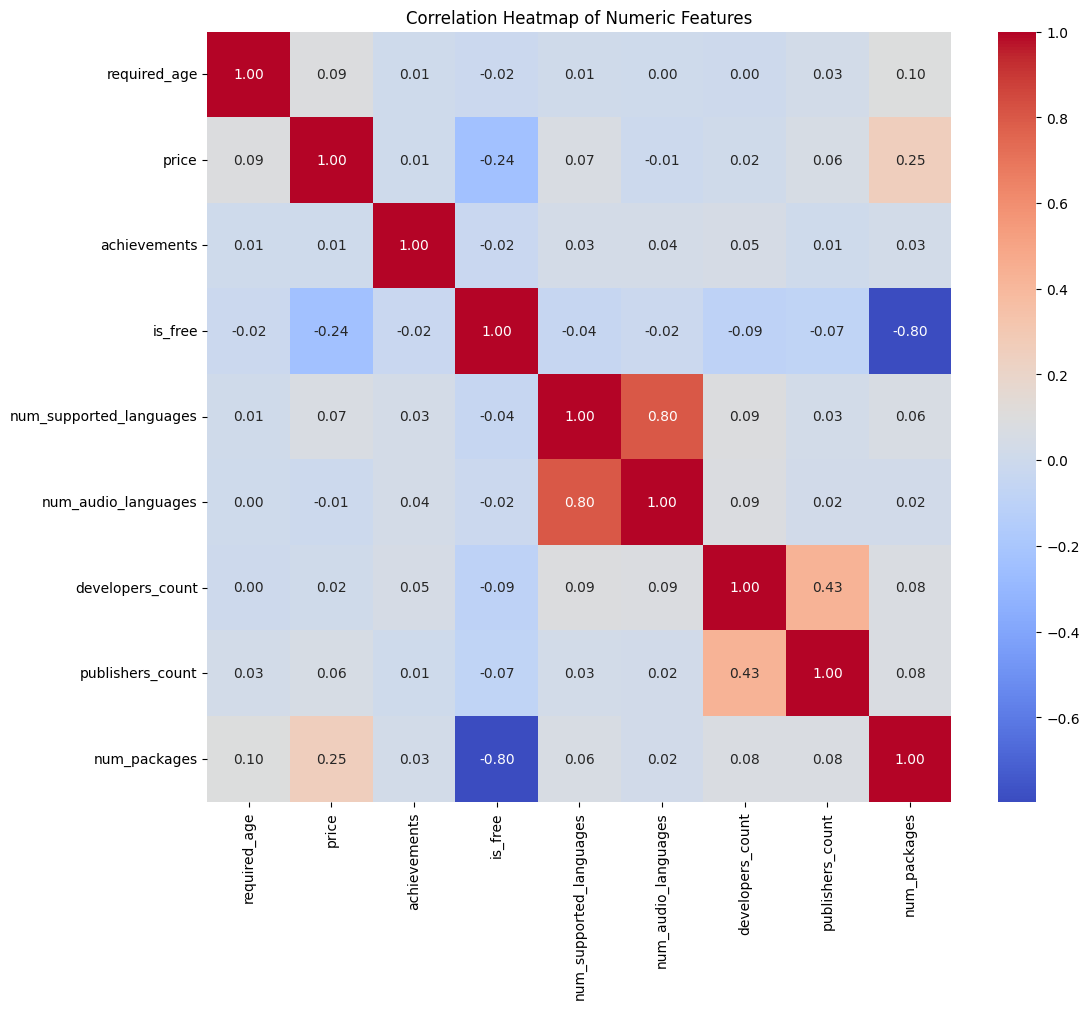

In [22]:
# plotting correlation heatmap of numeric columns
numeric_columns = fe_df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(12, 10))
sns.heatmap(fe_df[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

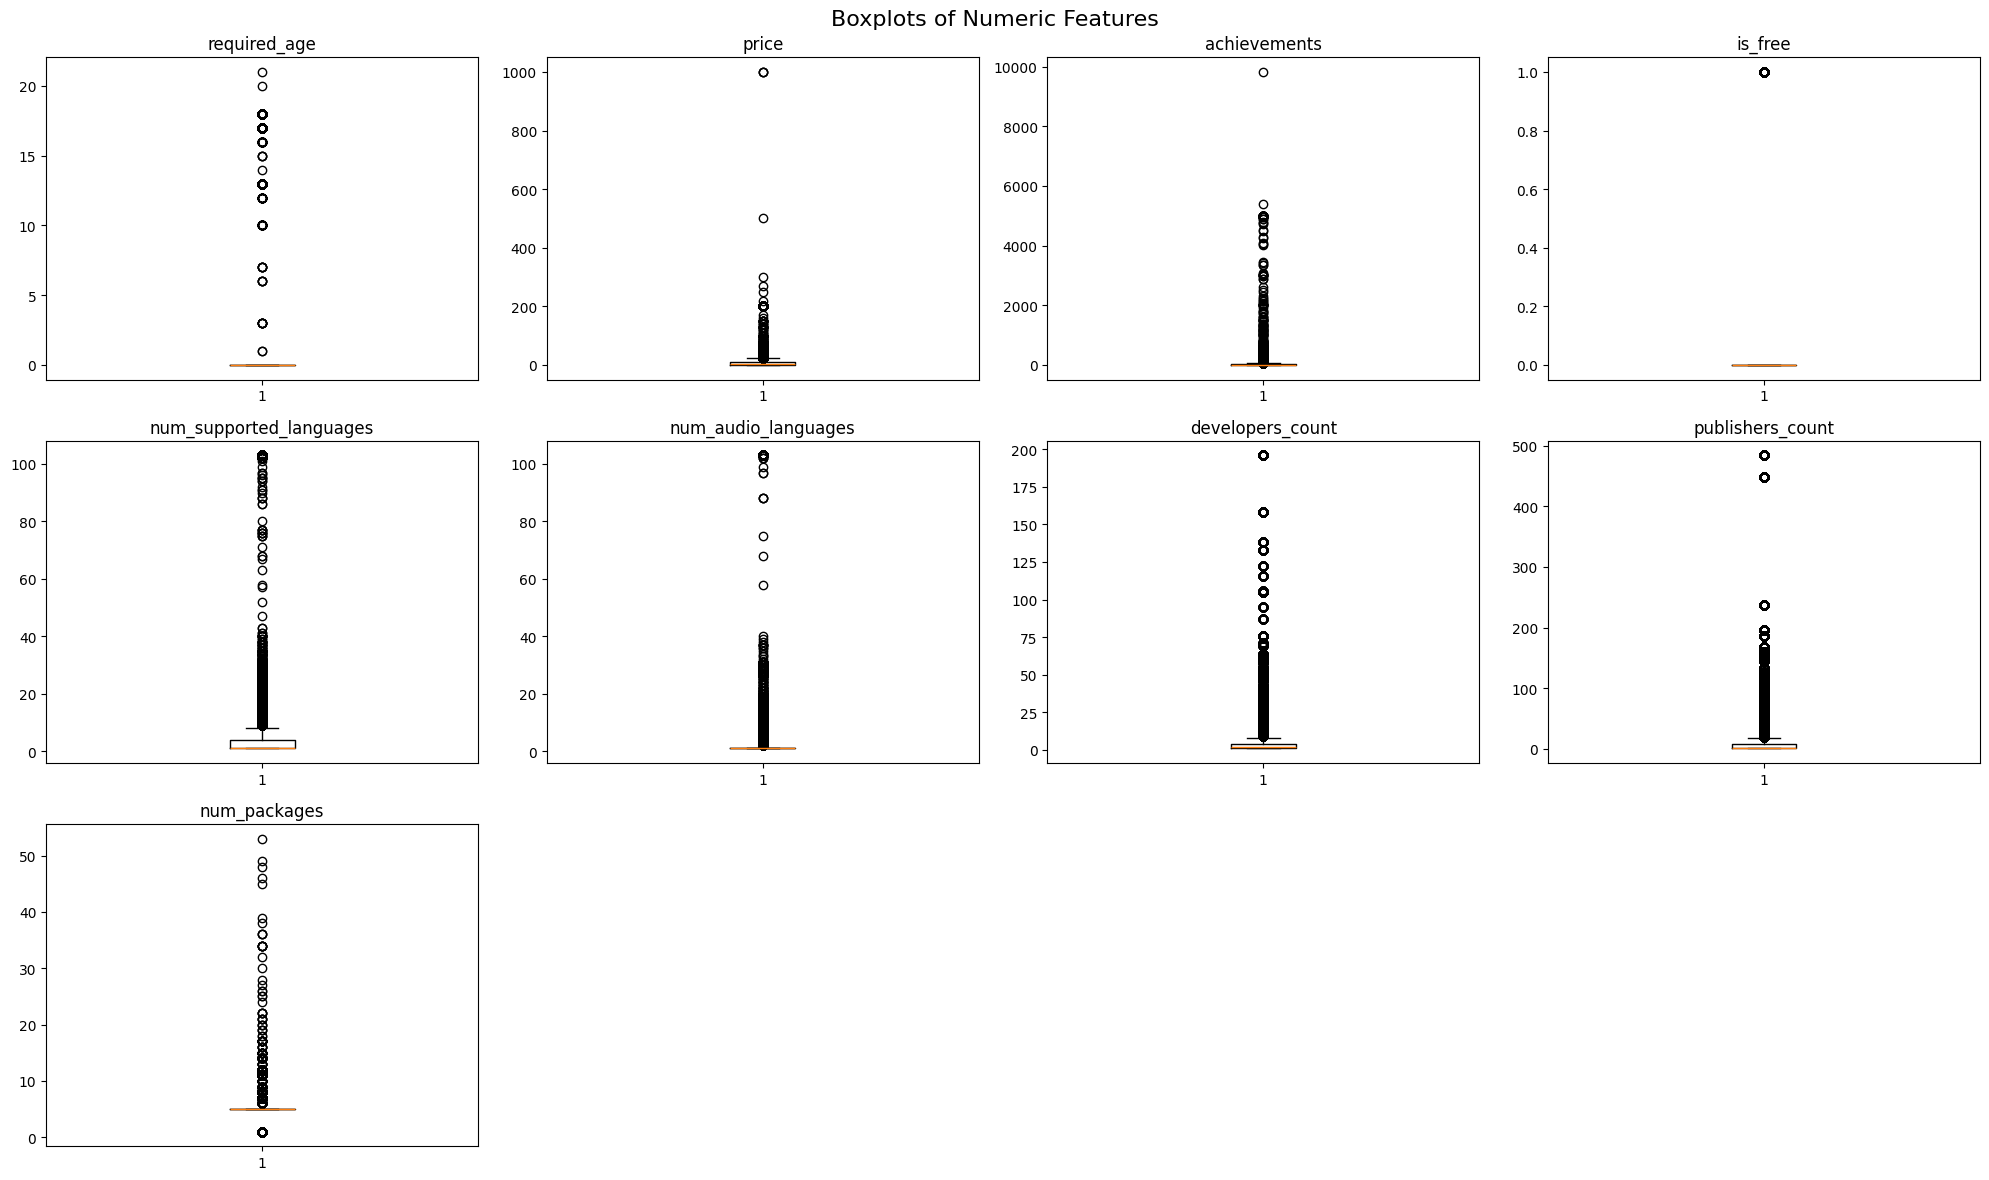

In [23]:
# plotting boxplots for numeric columns to check for outliers

num_cols = len(numeric_columns)
cols = 4
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(20, rows * 4))

plt.suptitle('Boxplots of Numeric Features', fontsize=16)

for i, col in enumerate(numeric_columns):
    plt.subplot(rows, cols, i + 1)
    plt.boxplot(fe_df[col].dropna())
    plt.title(col)

plt.subplots_adjust(top=0.92)
plt.tight_layout()
plt.show()

In [24]:
cols_to_log = [
    'achievements',
    'num_supported_languages',
    'num_audio_languages',
    'developers_count',
    'publishers_count',
    'num_packages'
]

for col in cols_to_log:
    fe_df[f'log_{col}'] = np.log1p(fe_df[col])

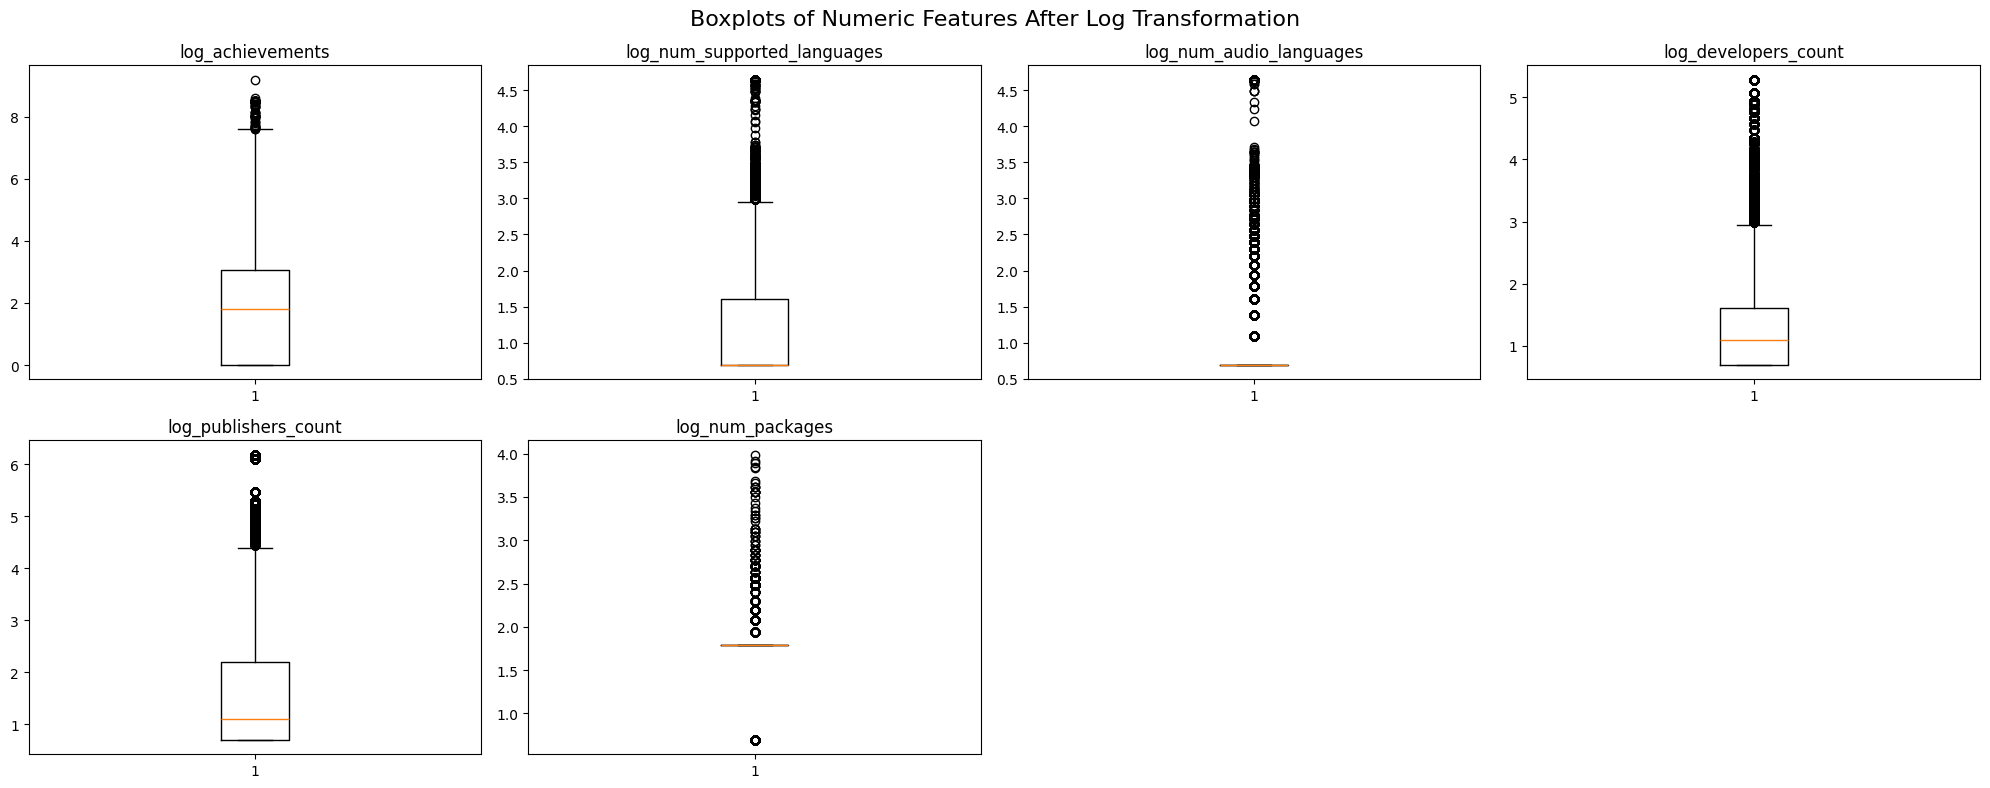

In [25]:
# plotting boxplots for numeric columns to check for outliers

log_cols = [col for col in fe_df.columns if col.startswith('log_')]
num_cols = len(log_cols)
cols = 4
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(20, rows * 4))

plt.suptitle('Boxplots of Numeric Features After Log Transformation', fontsize=16)

for i, col in enumerate(log_cols):
    plt.subplot(rows, cols, i + 1)
    plt.boxplot(fe_df[col].dropna())
    plt.title(col)

plt.subplots_adjust(top=0.92)
plt.tight_layout()
plt.show()

### **IMPLEMENTATIONS**

* Generated a **correlation matrix** to detect multicollinearity.

  * No highly correlated features were found.
  * `num_supported_languages` and `num_audio_languages` showed moderate correlation (~0.80), which is acceptable.

* Visualized numeric features using **boxplots** and observed significant **right-skewness** across most variables.

* Applied **log transformation (`log1p`)** to reduce skewness and stabilize variance.

  * Excluded:

    * `required_age` (categorical-like feature)
    * `price` (regression target)
    * `is_free` (binary feature)
  * Used `log1p` to safely handle zero values.

* Re-plotted boxplots after transformation, confirming **reduced skewness and improved distribution balance**.

---



In [ ]:
# exporting the cleaned and feature engineered DataFrame to a new CSV file for future use in modeling and analysis.
fe_df.to_csv('games_march2025_fe.csv', index=False)

## **CONCLUSION – DATA PREPROCESSING AND FEATURE ENGINEERING**

This phase focused on transforming the raw Steam dataset into a structured, modeling-ready format using only **pre-release predictive signals**.

Key outcomes from this phase include:

* Removed **irrelevant and high-null columns**, reducing noise and improving dataset quality.
* Dropped **post-release engagement features** (reviews, playtime, user counts, etc.) to ensure realistic pre-launch price prediction.
* Handled missing and placeholder values (e.g., converted `-1` where appropriate).
* Engineered meaningful predictive features such as:

  * `is_free`
  * Language counts
  * Developer and publisher counts/tier
  * `release_year`
  * `price_category`
* Performed **multicollinearity analysis**, confirming no critical high correlations.
* Identified heavy skewness in numerical features and applied **log transformation (`log1p`)** to stabilize distributions.
* Exported the finalized **feature-engineered dataset** for downstream modeling.

The dataset is now clean, structured, normalized, and aligned with the project objective of predicting game price before release.

---

### ✅ **PHASE 02 – DATA PREPROCESSING AND FEATURE ENGINEERING COMPLETED**

➡ Moving to **Phase 03 – Model Training**

---
